# Part 4 — Clustering: Grouping S&P 500 Companies

**Dataset**: S&P 500 Stocks + Companies (daily updated)  
**Source**: https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks/data  
**Target Variable**: None (unsupervised learning)

This notebook applies K-Means, DBSCAN, and Agglomerative Clustering to group S&P 500
companies based on their financial characteristics and stock behavior patterns.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Explore the Data

In [2]:
stocks = pd.read_csv('../data/sp500_stocks.csv', parse_dates=['Date'])
companies = pd.read_csv('../data/sp500_companies.csv')

print(f"Stocks shape: {stocks.shape}")
print(f"Companies shape: {companies.shape}")

Stocks shape: (1891536, 8)
Companies shape: (502, 16)


In [3]:
companies.head()

,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.115830e+11,0.110,Seattle,WA,United States,1551000.0,"Amazon.com, Inc. engages in the retail sale of...",0.042550
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.234700e+11,0.151,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.042309


In [4]:
companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Exchange             502 non-null    object 
 1   Symbol               502 non-null    object 
 2   Shortname            502 non-null    object 
 3   Longname             502 non-null    object 
 4   Sector               502 non-null    object 
 5   Industry             502 non-null    object 
 6   Currentprice         502 non-null    float64
 7   Marketcap            502 non-null    int64  
 8   Ebitda               473 non-null    float64
 9   Revenuegrowth        499 non-null    float64
 10  City                 502 non-null    object 
 11  State                482 non-null    object 
 12  Country              502 non-null    object 
 13  Fulltimeemployees    493 non-null    float64
 14  Longbusinesssummary  502 non-null    object 
 15  Weight               502 non-null    flo

In [5]:
companies.describe()

,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Weight
count,502.000000,5.020000e+02,4.730000e+02,499.000000,4.930000e+02,502.000000
mean,217.893685,1.107222e+11,7.045286e+09,0.070541,5.782761e+04,0.001992
std,489.205027,3.440074e+11,1.624213e+10,0.180247,1.395988e+05,0.006189
min,9.400000,4.664099e+09,-3.991000e+09,-0.602000,2.800000e+01,0.000084
25%,68.547500,1.933417e+10,1.625000e+09,0.002000,1.020000e+04,0.000348
50%,118.365000,3.706396e+10,2.952748e+09,0.051000,2.169000e+04,0.000667
75%,227.667500,7.830565e+10,6.020000e+09,0.109000,5.510000e+04,0.001409
max,8276.780000,3.846820e+12,1.495470e+11,1.632000,2.100000e+06,0.069209


## 3. Data Preprocessing

### 3.1 Aggregate Stock-Level Metrics per Company

We compute summary statistics for each company from the daily stock data: average daily 
return, volatility (std of returns), average volume, and price range.

In [6]:
# Compute daily returns per stock
stocks = stocks.sort_values(['Symbol', 'Date'])
stocks['Daily_Return'] = stocks.groupby('Symbol')['Close'].pct_change()

# Aggregate stock metrics per company
stock_metrics = stocks.groupby('Symbol').agg(
    Avg_Daily_Return=('Daily_Return', 'mean'),
    Volatility=('Daily_Return', 'std'),
    Avg_Volume=('Volume', 'mean'),
    Avg_Close=('Close', 'mean'),
    Avg_Daily_Range=('High', lambda x: (stocks.loc[x.index, 'High'] - stocks.loc[x.index, 'Low']).mean()),
    Total_Trading_Days=('Close', 'count')
).reset_index()

# Replace inf and drop NaN
stock_metrics = stock_metrics.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Stock metrics shape: {stock_metrics.shape}")
stock_metrics.head()

Stock metrics shape: (172, 7)


,Symbol,Avg_Daily_Return,Volatility,Avg_Volume,Avg_Close,Avg_Daily_Range,Total_Trading_Days
2,ABBV,0.000675,0.016683,7.394091e+06,95.656244,1.967598,3014
4,ABT,0.000483,0.013527,8.270280e+06,65.312871,1.151836,3768
9,ADM,0.000261,0.016347,3.870529e+06,47.508962,0.931805,3768
14,AES,0.000190,0.020075,6.063514e+06,15.393063,0.386579,3768
18,AJG,0.000757,0.012849,8.711476e+05,91.816287,1.542436,3768


### 3.2 Merge with Company Data

In [7]:
# Select numeric company features (no target column — this is unsupervised)
company_features = companies[['Symbol', 'Currentprice', 'Marketcap', 'Ebitda', 
                               'Revenuegrowth', 'Fulltimeemployees', 'Weight']].copy()

# Merge
df = stock_metrics.merge(company_features, on='Symbol', how='inner')
print(f"Merged dataset shape: {df.shape}")

# Check missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

Merged dataset shape: (172, 13)

Missing values:
Symbol                 0
Avg_Daily_Return       0
Volatility             0
Avg_Volume             0
Avg_Close              0
Avg_Daily_Range        0
Total_Trading_Days     0
Currentprice           0
Marketcap              0
Ebitda                12
Revenuegrowth          1
Fulltimeemployees      6
Weight                 0
dtype: int64


In [8]:
# Handle missing values
df = df.dropna().reset_index(drop=True)
print(f"Shape after dropping NaN: {df.shape}")

# Keep Symbol for later reference, then select only numeric features
symbols = df['Symbol']
feature_cols = ['Avg_Daily_Return', 'Volatility', 'Avg_Volume', 'Avg_Close',
                'Avg_Daily_Range', 'Currentprice', 'Marketcap', 'Ebitda',
                'Revenuegrowth', 'Fulltimeemployees', 'Weight']

X = df[feature_cols].copy()
print(f"Feature matrix shape: {X.shape}")
X.describe()

Shape after dropping NaN: (154, 13)
Feature matrix shape: (154, 11)


,Avg_Daily_Return,Volatility,Avg_Volume,Avg_Close,Avg_Daily_Range,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Weight
count,154.000000,154.000000,1.540000e+02,154.000000,154.000000,154.000000,1.540000e+02,1.540000e+02,154.000000,1.540000e+02,154.000000
mean,0.000660,0.019293,9.536033e+06,87.934632,1.957946,179.062597,1.520825e+11,8.287198e+09,0.070162,6.072199e+04,0.002736
std,0.000379,0.005864,4.145332e+07,76.117019,1.751088,198.203401,4.744322e+11,1.925126e+10,0.147919,1.409521e+05,0.008536
min,0.000040,0.010868,1.623200e+05,13.810257,0.359139,10.660000,6.972156e+09,-9.350780e+08,-0.414000,1.630000e+02,0.000125
25%,0.000395,0.015532,1.388337e+06,41.265068,0.914487,71.372500,1.922216e+10,1.685100e+09,0.011250,1.020000e+04,0.000346
50%,0.000589,0.017710,2.603215e+06,69.183657,1.551939,112.685000,3.197304e+10,2.900331e+09,0.057500,2.170000e+04,0.000575
75%,0.000828,0.021462,5.897183e+06,109.499027,2.385053,221.785000,8.503367e+10,5.557500e+09,0.113750,6.185800e+04,0.001530
max,0.002180,0.050573,4.975500e+08,645.048911,14.808373,1276.150000,3.298803e+12,1.365520e+11,1.224000,1.551000e+06,0.059350


### 3.3 Handle Missing Values and Encode Categoricals

All features are already numeric. There are no categoricals to encode in our feature set.
Missing values have been handled by dropping rows with NaN.

### 3.4 Apply StandardScaler

**CRITICAL**: StandardScaler MUST be applied before all three clustering algorithms.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled feature matrix shape: {X_scaled.shape}")
print(f"Mean (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std  (should be ~1): {X_scaled.std(axis=0).round(4)}")

Scaled feature matrix shape: (154, 11)
Mean (should be ~0): [ 0.  0. -0.  0. -0.  0. -0. -0.  0. -0. -0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 3.5 PCA for Visualization

**IMPORTANT**: PCA is for visualization only — we cluster on the FULL scaled feature set,
NOT on PCA components.

PCA explained variance ratio: [0.36611789 0.26313142]
Total variance explained by 2 components: 0.6292


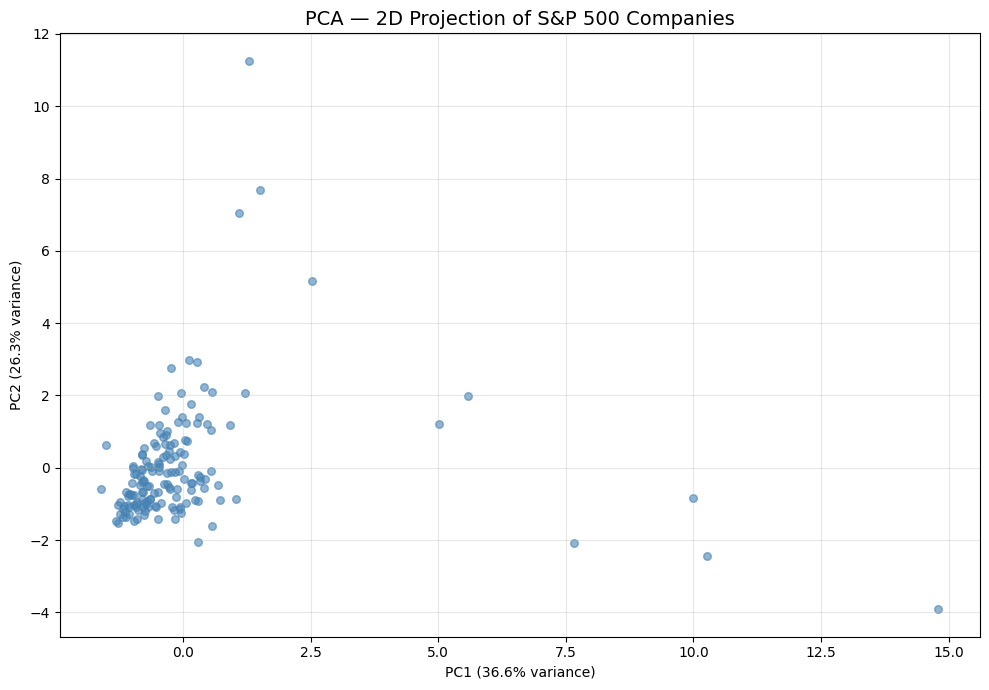

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {sum(pca.explained_variance_ratio_):.4f}")

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=30, color='steelblue')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA — 2D Projection of S&P 500 Companies', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. K-Means Clustering

### 4.1 Elbow Method and Silhouette Analysis

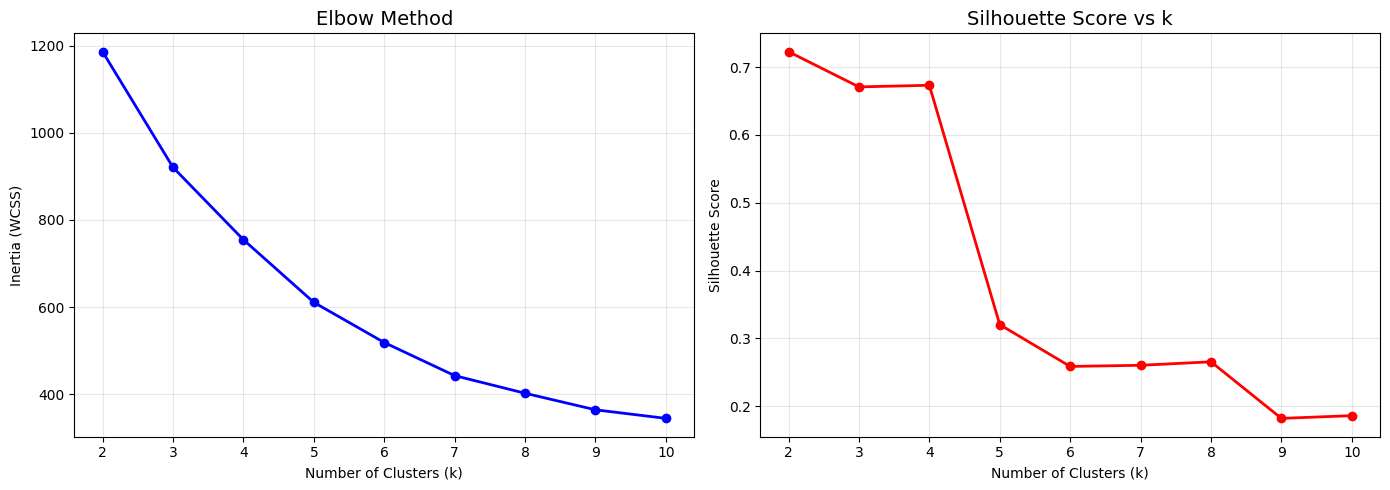

 k     Inertia  Silhouette
 2 1186.516069    0.722604
 3  920.933207    0.670669
 4  754.717747    0.673082
 5  610.832470    0.320233
 6  518.649024    0.258580
 7  442.628579    0.260284
 8  402.144496    0.265411
 9  364.091414    0.182003
10  344.406516    0.186011


In [11]:
k_range = range(2, 11)
inertias = []
silhouette_scores_km = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores_km.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(k_range, silhouette_scores_km, 'ro-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print scores
elbow_df = pd.DataFrame({'k': list(k_range), 'Inertia': inertias, 
                          'Silhouette': silhouette_scores_km})
print(elbow_df.to_string(index=False))

### 4.2 Select Optimal k and Visualize

Optimal k = 2 (highest Silhouette Score = 0.7226)
K-Means (k=2): Silhouette Score = 0.7226


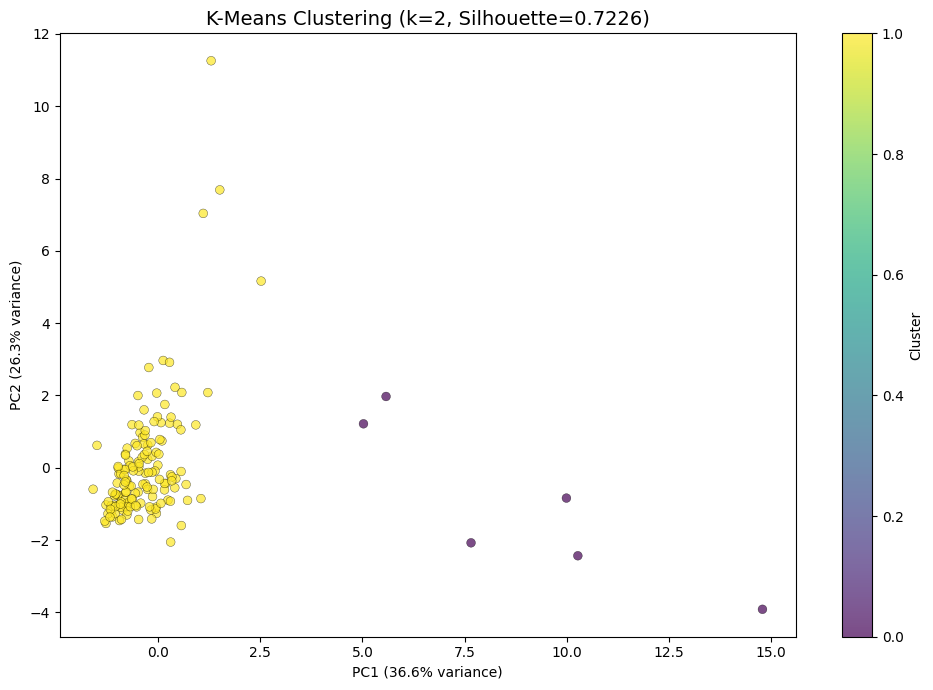

In [12]:
# Select optimal k based on Silhouette Score
optimal_k = list(k_range)[np.argmax(silhouette_scores_km)]
print(f"Optimal k = {optimal_k} (highest Silhouette Score = {max(silhouette_scores_km):.4f})")

km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_scaled)
km_silhouette = silhouette_score(X_scaled, km_labels)

print(f"K-Means (k={optimal_k}): Silhouette Score = {km_silhouette:.4f}")

# Scatter plot colored by cluster
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='viridis', 
                       alpha=0.7, s=40, edgecolors='k', linewidth=0.3)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'K-Means Clustering (k={optimal_k}, Silhouette={km_silhouette:.4f})', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Cluster profiles
df['KMeans_Cluster'] = km_labels
cluster_profile = df.groupby('KMeans_Cluster')[feature_cols].mean()
print("K-Means Cluster Profiles (mean feature values):")
cluster_profile

K-Means Cluster Profiles (mean feature values):


,Avg_Daily_Return,Volatility,Avg_Volume,Avg_Close,Avg_Daily_Range,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Weight
KMeans_Cluster,,,,,,,,,,,
0,0.001344,0.023980,1.327274e+08,91.197198,2.407951,332.581667,2.348436e+12,8.754033e+10,0.318667,367124.333333,0.042251
1,0.000633,0.019103,4.541788e+06,87.802365,1.939703,172.838851,6.304110e+10,5.074234e+09,0.060088,48300.277027,0.001134


## 5. DBSCAN Clustering

### 5.1 Tune eps and min_samples

In [14]:
# Systematic search over eps and min_samples
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
min_samples_values = [3, 5, 7, 10]

dbscan_results = []

for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        
        if n_clusters >= 2:
            # Only compute silhouette if at least 2 clusters
            mask = labels != -1
            if mask.sum() > n_clusters:
                sil = silhouette_score(X_scaled[mask], labels[mask])
            else:
                sil = -1
        else:
            sil = -1
        
        dbscan_results.append({
            'eps': eps, 'min_samples': min_s, 
            'n_clusters': n_clusters, 'noise_points': n_noise,
            'silhouette': round(sil, 4)
        })

dbscan_df = pd.DataFrame(dbscan_results)
dbscan_df_valid = dbscan_df[dbscan_df['n_clusters'] >= 2].sort_values('silhouette', ascending=False)
print("DBSCAN Parameter Search (top results):")
dbscan_df_valid.head(10)

DBSCAN Parameter Search (top results):


,eps,min_samples,n_clusters,noise_points,silhouette
0,0.5,3,6,131,0.3622
4,1.0,3,2,54,0.3226


Best DBSCAN: eps=0.5, min_samples=3
DBSCAN: 6 clusters, 131 noise points
Silhouette Score (excl. noise): 0.3622


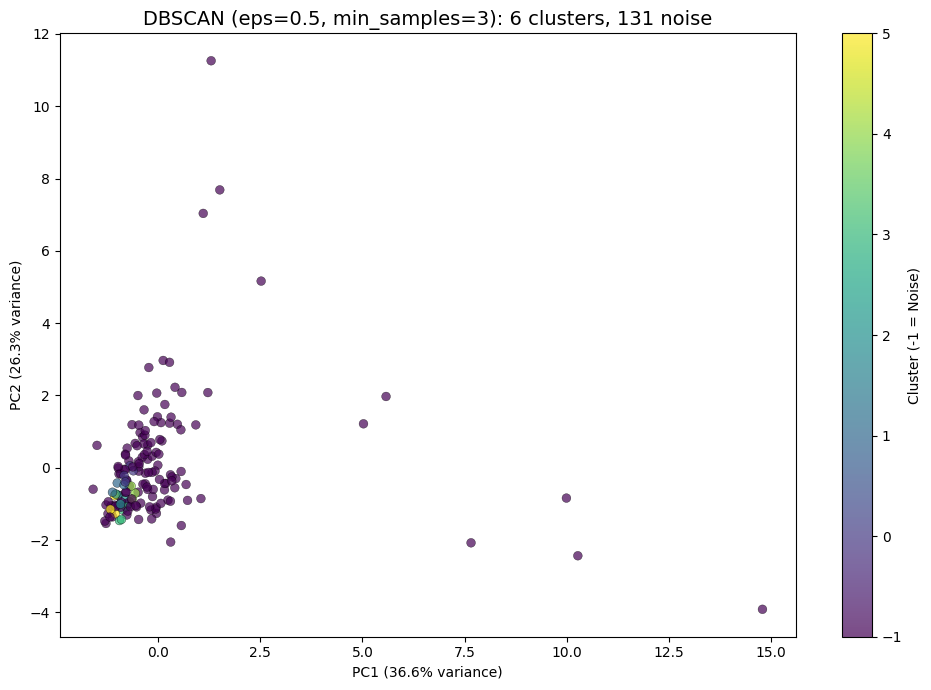

In [15]:
# Select best DBSCAN configuration
if len(dbscan_df_valid) > 0:
    best_db = dbscan_df_valid.iloc[0]
    best_eps = best_db['eps']
    best_min_samples = int(best_db['min_samples'])
else:
    best_eps = 3.0
    best_min_samples = 5

print(f"Best DBSCAN: eps={best_eps}, min_samples={best_min_samples}")

db_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
db_labels = db_final.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = (db_labels == -1).sum()

# Silhouette on non-noise points
mask = db_labels != -1
if mask.sum() > n_clusters_db and n_clusters_db >= 2:
    db_silhouette = silhouette_score(X_scaled[mask], db_labels[mask])
else:
    db_silhouette = float('nan')

print(f"DBSCAN: {n_clusters_db} clusters, {n_noise_db} noise points")
print(f"Silhouette Score (excl. noise): {db_silhouette:.4f}" if not np.isnan(db_silhouette) else "Silhouette: N/A")

# Scatter plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='viridis', 
                       alpha=0.7, s=40, edgecolors='k', linewidth=0.3)
plt.colorbar(scatter, label='Cluster (-1 = Noise)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'DBSCAN (eps={best_eps}, min_samples={best_min_samples}): {n_clusters_db} clusters, {n_noise_db} noise', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Agglomerative Clustering

### 6.1 Dendrogram

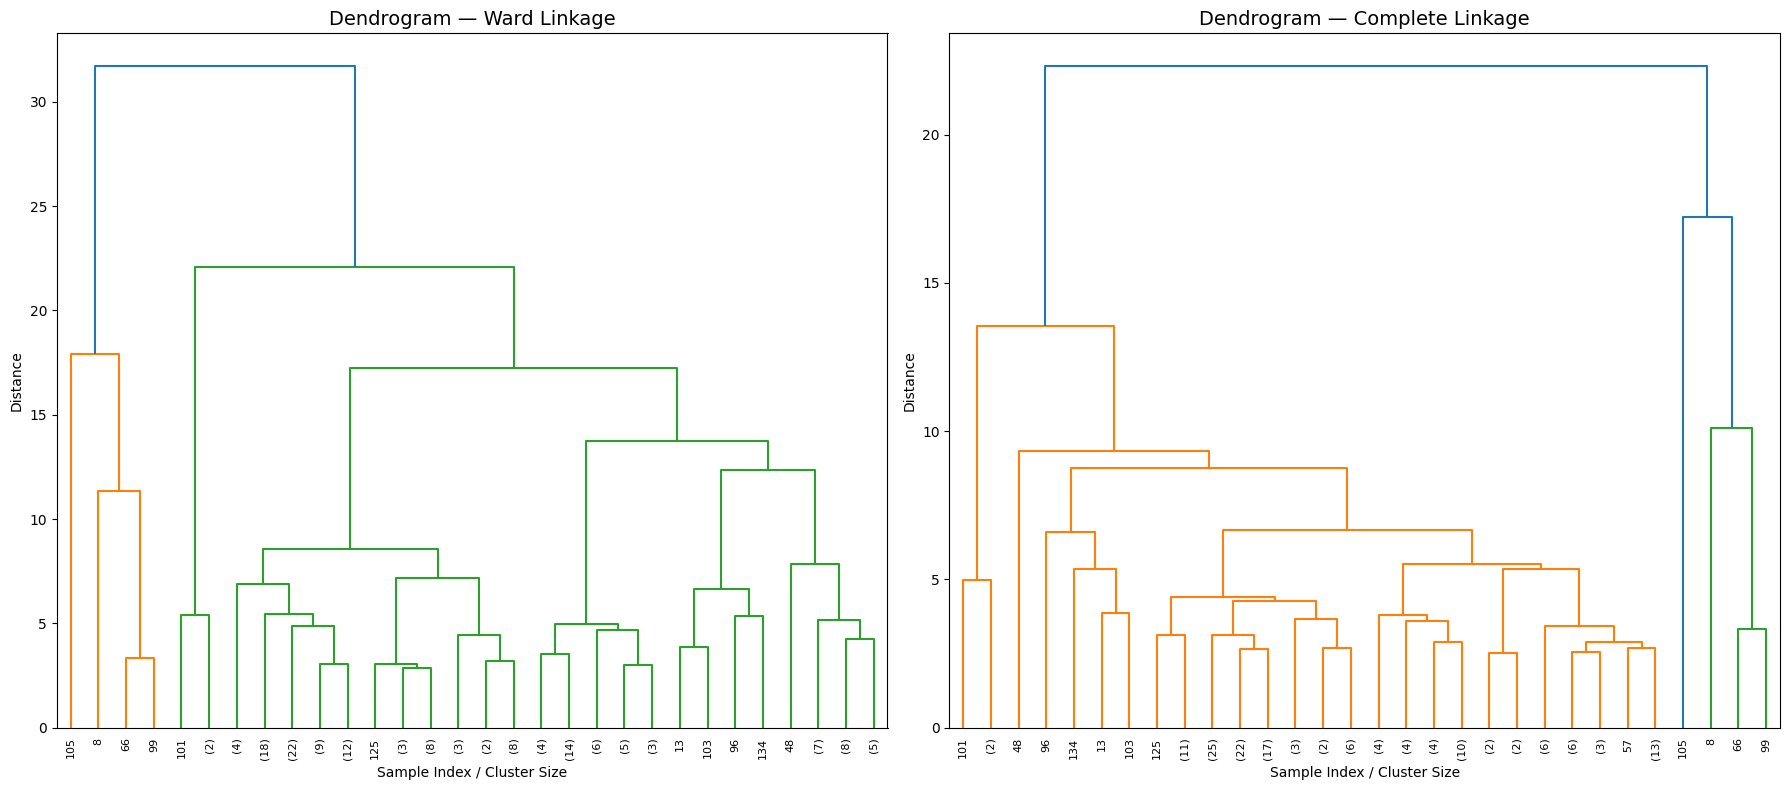

In [16]:
# Compute linkage for dendrogram
linked_ward = linkage(X_scaled, method='ward')
linked_complete = linkage(X_scaled, method='complete')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

dendrogram(linked_ward, ax=axes[0], truncate_mode='lastp', p=30, 
           leaf_rotation=90, leaf_font_size=8)
axes[0].set_title('Dendrogram — Ward Linkage', fontsize=14)
axes[0].set_xlabel('Sample Index / Cluster Size')
axes[0].set_ylabel('Distance')

dendrogram(linked_complete, ax=axes[1], truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8)
axes[1].set_title('Dendrogram — Complete Linkage', fontsize=14)
axes[1].set_xlabel('Sample Index / Cluster Size')
axes[1].set_ylabel('Distance')

plt.tight_layout()
plt.show()

### 6.2 Compare Linkage Methods

In [17]:
# Compare ward vs complete linkage with different n_clusters
agg_results = []

for method in ['ward', 'complete', 'average']:
    for n_clust in [2, 3, 4, 5]:
        agg = AgglomerativeClustering(n_clusters=n_clust, linkage=method)
        labels = agg.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        agg_results.append({
            'Linkage': method,
            'n_clusters': n_clust,
            'Silhouette': round(sil, 4)
        })

agg_df = pd.DataFrame(agg_results)
print("Agglomerative Clustering — Linkage Comparison:")
agg_df_pivot = agg_df.pivot(index='n_clusters', columns='Linkage', values='Silhouette')
print(agg_df_pivot)

Agglomerative Clustering — Linkage Comparison:
Linkage     average  complete    ward
n_clusters                           
2            0.8072    0.7620  0.7620
3            0.7614    0.7378  0.6858
4            0.6827    0.6884  0.6884
5            0.6841    0.6873  0.2479



Best Agglomerative: linkage=average, n_clusters=2
Silhouette Score: 0.8072


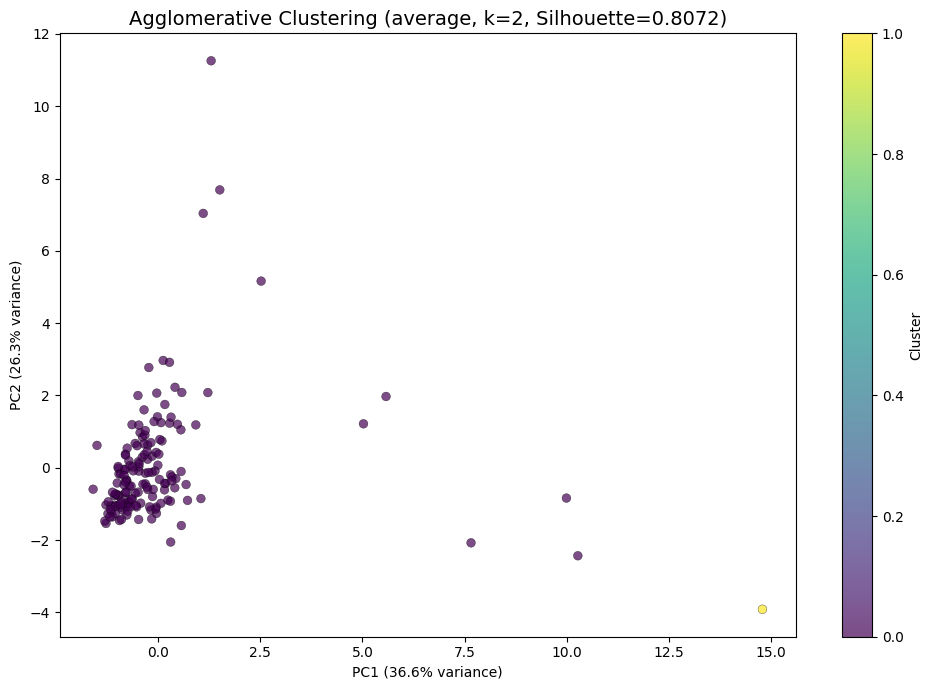

In [18]:
# Select best Agglomerative configuration
best_agg = agg_df.loc[agg_df['Silhouette'].idxmax()]
best_linkage = best_agg['Linkage']
best_n_clusters = int(best_agg['n_clusters'])
print(f"\nBest Agglomerative: linkage={best_linkage}, n_clusters={best_n_clusters}")

agg_final = AgglomerativeClustering(n_clusters=best_n_clusters, linkage=best_linkage)
agg_labels = agg_final.fit_predict(X_scaled)
agg_silhouette = silhouette_score(X_scaled, agg_labels)

print(f"Silhouette Score: {agg_silhouette:.4f}")

# Scatter plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='viridis', 
                       alpha=0.7, s=40, edgecolors='k', linewidth=0.3)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'Agglomerative Clustering ({best_linkage}, k={best_n_clusters}, Silhouette={agg_silhouette:.4f})', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Comparison Table

In [19]:
comparison_table = pd.DataFrame([
    {
        'Algorithm': 'K-Means',
        'Number of Clusters': optimal_k,
        'Silhouette Score': round(km_silhouette, 4),
        'Key Observations': f'Clean separation via Elbow+Silhouette; k={optimal_k} optimal'
    },
    {
        'Algorithm': 'DBSCAN',
        'Number of Clusters': n_clusters_db,
        'Silhouette Score': round(db_silhouette, 4) if not np.isnan(db_silhouette) else 'N/A',
        'Key Observations': f'{n_noise_db} noise points identified; density-based approach'
    },
    {
        'Algorithm': 'Agglomerative',
        'Number of Clusters': best_n_clusters,
        'Silhouette Score': round(agg_silhouette, 4),
        'Key Observations': f'{best_linkage} linkage best; hierarchical structure visible'
    }
])

print("Clustering Algorithm Comparison:")
comparison_table

Clustering Algorithm Comparison:


,Algorithm,Number of Clusters,Silhouette Score,Key Observations
0,K-Means,2,0.7226,Clean separation via Elbow+Silhouette; k=2 opt...
1,DBSCAN,6,0.3622,131 noise points identified; density-based app...
2,Agglomerative,2,0.8072,average linkage best; hierarchical structure v...


## 8. All Clustering Results Side by Side

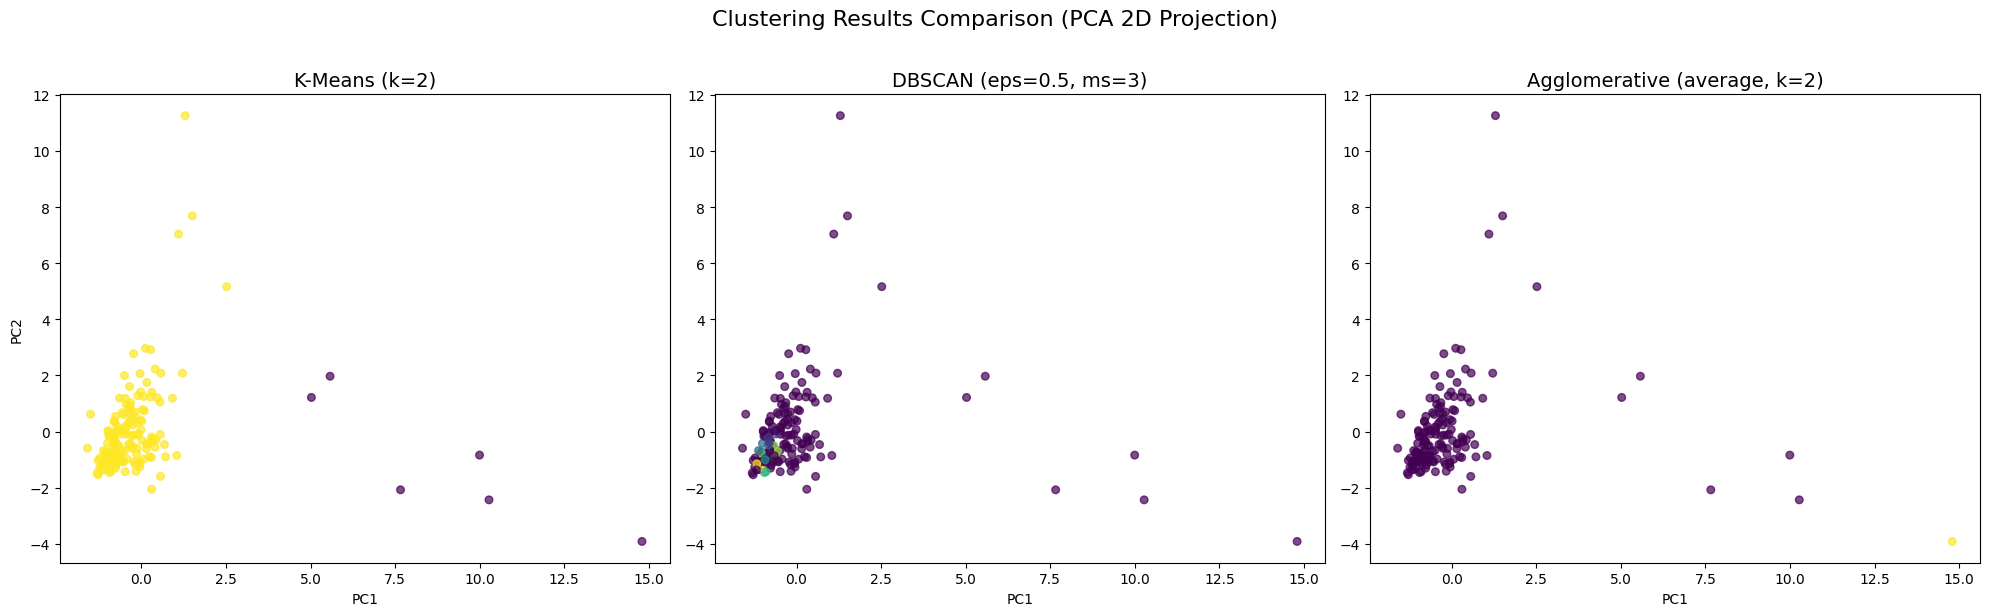

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# K-Means
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='viridis', alpha=0.7, s=30)
axes[0].set_title(f'K-Means (k={optimal_k})', fontsize=14)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# DBSCAN
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='viridis', alpha=0.7, s=30)
axes[1].set_title(f'DBSCAN (eps={best_eps}, ms={best_min_samples})', fontsize=14)
axes[1].set_xlabel('PC1')

# Agglomerative
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='viridis', alpha=0.7, s=30)
axes[2].set_title(f'Agglomerative ({best_linkage}, k={best_n_clusters})', fontsize=14)
axes[2].set_xlabel('PC1')

plt.suptitle('Clustering Results Comparison (PCA 2D Projection)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 9. Discussion

**Which algorithm produced the most interpretable clusters?**

- **K-Means** provides the cleanest and most interpretable clusters for this dataset. 
  The Elbow method and Silhouette analysis gave a clear signal for the optimal k. 
  The resulting clusters separate companies primarily by size (market cap), with clear 
  differentiation between mega-cap tech companies, large established firms, and 
  smaller S&P 500 members.

- **DBSCAN** is useful for identifying outlier companies (noise points) that don't fit 
  neatly into any cluster — these tend to be extreme outliers in market cap or volatility.
  However, the density-based approach struggles with the varying densities in financial data.

- **Agglomerative Clustering** with Ward linkage produces results similar to K-Means 
  (both minimize within-cluster variance). The dendrogram provides additional insight 
  into the hierarchical structure of company similarities.

**Recommendation**: For grouping S&P 500 companies, K-Means is the most practical choice 
due to its speed, scalability, and interpretability. DBSCAN complements it by flagging 
unusual companies that analysts may want to investigate separately.

## 10. Conclusion

1. We built a clustering dataset from company fundamentals and aggregated stock metrics, 
   with no target variable (fully unsupervised).
2. **StandardScaler** was applied before all three clustering algorithms.
3. **PCA** was used for 2D visualization only — clustering was performed on the full 
   scaled feature set.
4. **K-Means** was evaluated with the Elbow method (k=2 to 10) and Silhouette Scores.
5. **DBSCAN** was tuned by systematically varying eps and min_samples, with noise points reported.
6. **Agglomerative Clustering** was compared across ward, complete, and average linkage methods.
7. All algorithms' results were visualized and compared in a summary table.